In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)
print("All imports successful!")

TensorFlow version: 2.21.0
All imports successful!


In [2]:
base_dir = '../datasets/spiral/Spiral Drawing Images/spiral'
train_dir = os.path.join(base_dir, 'training')
test_dir = os.path.join(base_dir, 'testing')

print("Training path:", train_dir)
print("Testing path:", test_dir)
print("\nTraining classes:", os.listdir(train_dir))
print("Testing classes:", os.listdir(test_dir))

Training path: ../datasets/spiral/Spiral Drawing Images/spiral/training
Testing path: ../datasets/spiral/Spiral Drawing Images/spiral/testing

Training classes: ['healthy', 'parkinson']
Testing classes: ['.DS_Store', 'healthy', 'parkinson']


In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nClass indices:", train_generator.class_indices)

Found 72 images belonging to 2 classes.
Found 30 images belonging to 2 classes.

Class indices: {'healthy': 0, 'parkinson': 1}


In [4]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [6]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.5139 - loss: 0.7363 - val_accuracy: 0.5000 - val_loss: 0.6960
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.4167 - loss: 0.7196 - val_accuracy: 0.5000 - val_loss: 0.6952
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.4861 - loss: 0.6947 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4861 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.6979
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5000 - loss: 0.7107 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5417 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5694 - loss: 0.6973 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.4028 - loss: 0.7037 - val_accuracy: 0.5000 - val_loss: 0.6

In [7]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
print("SSL fix applied!")

SSL fix applied!


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Transfer learning model ready!")

Transfer learning model ready!


In [9]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step - accuracy: 0.5000 - loss: 0.8056 - val_accuracy: 0.5333 - val_loss: 0.6963
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5972 - loss: 0.7036 - val_accuracy: 0.6333 - val_loss: 0.6615
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5833 - loss: 0.6760 - val_accuracy: 0.6333 - val_loss: 0.6412
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6806 - loss: 0.6291 - val_accuracy: 0.7000 - val_loss: 0.6138
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5972 - loss: 0.6744 - val_accuracy: 0.7333 - val_loss: 0.5927
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5556 - loss: 0.7407 - val_accuracy: 0.7333 - val_loss: 0.5765
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6806 - loss: 0.6281 - val_accuracy: 0.7333 - val_loss: 0.5664
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7361 - loss: 0.6049 - val_accuracy: 0.7333 - val_loss: 0.5601

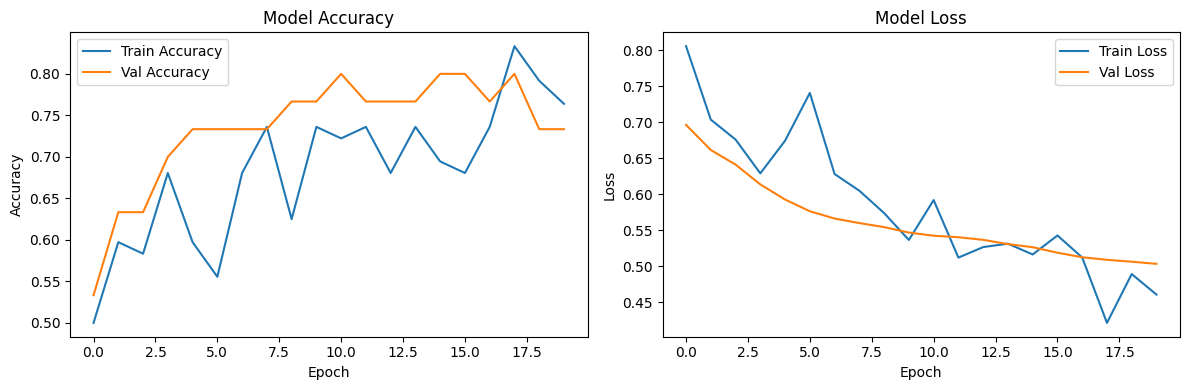

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
test_generator.reset()
loss, accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7333 - loss: 0.5036

Test Accuracy: 73.33%
Test Loss: 0.5036


In [12]:
import os
os.makedirs('../backend/models', exist_ok=True)

model.save('../backend/models/spiral_model.keras')
print("Spiral model saved successfully!")
print("Saved to: backend/models/spiral_model.keras")

Spiral model saved successfully!
Saved to: backend/models/spiral_model.keras


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Much more aggressive augmentation this time
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)

Found 72 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Class indices: {'healthy': 0, 'parkinson': 1}
Training samples: 72


In [14]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Rebuild transfer learning model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

new_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

new_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping prevents overfitting
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

print("Training with augmented data...")
history2 = new_model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stop],
    verbose=1
)

Training with augmented data...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - accuracy: 0.4444 - loss: 0.8371 - val_accuracy: 0.5333 - val_loss: 0.6724
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5556 - loss: 0.7204 - val_accuracy: 0.5667 - val_loss: 0.6413
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5139 - loss: 0.7442 - val_accuracy: 0.6667 - val_loss: 0.6093
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5139 - loss: 0.7448 - val_accuracy: 0.7000 - val_loss: 0.5866
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5417 - loss: 0.7057 - val_accuracy: 0.8000 - val_loss: 0.5731
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4861 - loss: 0.7170 - val_accuracy: 0.7667 - val_loss: 0.5669
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6389 - loss: 0.6536 - val_accuracy: 0.8000 - val_loss: 0.5550
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5833 - loss: 0.7027 - val_acc

In [15]:
# Evaluate final model
loss, accuracy = new_model.evaluate(test_generator, verbose=1)
print(f"\nFinal Test Accuracy: {accuracy * 100:.2f}%")

# Save the new improved model
import os
os.makedirs('../backend/models', exist_ok=True)
new_model.save('../backend/models/spiral_model.keras')
print("✅ Improved spiral model saved!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8000 - loss: 0.5731

Final Test Accuracy: 80.00%
✅ Improved spiral model saved!


In [16]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# New combined dataset paths
train_dir = '../datasets/spiral/combined/training'
test_dir = '../datasets/spiral/combined/testing'

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Testing samples:", test_generator.samples)

Found 2972 images belonging to 2 classes.
Found 832 images belonging to 2 classes.
Class indices: {'healthy': 0, 'parkinson': 1}
Training samples: 2972
Testing samples: 832


In [17]:
# Build transfer learning model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

combined_spiral_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

combined_spiral_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

print("Training on combined dataset...")
history3 = combined_spiral_model.fit(
    train_generator,
    epochs=30,
    validation_data=test_generator,
    callbacks=[early_stop],
    verbose=1
)

Training on combined dataset...
Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.6077 - loss: 0.6791 - val_accuracy: 0.7464 - val_loss: 0.5469
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.7207 - loss: 0.5453 - val_accuracy: 0.7800 - val_loss: 0.4858
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7487 - loss: 0.5004 - val_accuracy: 0.7668 - val_loss: 0.4758
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.7665 - loss: 0.4849 - val_accuracy: 0.7764 - val_loss: 0.4624
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.7843 - loss: 0.4530 - val_accuracy: 0.7885 - val_loss: 0.4397
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.8072 - loss: 0.4319 - val_accuracy: 0.7909 - val_loss: 0.4247
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8119 - loss: 0.4035 - val_accuracy: 0.7945 - val_loss: 0.4271
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8197 - loss: 

In [ ]:
# Evaluate
loss, accuracy = combined_spiral_model.evaluate(test_generator, verbose=1)
print(f"\nFinal Test Accuracy: {accuracy * 100:.2f}%")

# Save
import os
os.makedirs('../backend/models', exist_ok=True)
combined_spiral_model.save('../backend/models/spiral_model.keras')
print("✅ Combined spiral model saved!")

19/26 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8829 - loss: 0.2820

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Use only augmented_hw_dataset
train_dir = '../datasets/spiral/augmented_hw_dataset/spiral/training'
test_dir = '../datasets/spiral/augmented_hw_dataset/spiral/testing'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Testing samples:", test_generator.samples)

Found 288 images belonging to 2 classes.
Found 150 images belonging to 2 classes.
Class indices: {'healthy': 0, 'parkinson': 1}
Training samples: 288
Testing samples: 150


In [2]:
# Build model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

hw_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

hw_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

print("Training on augmented_hw_dataset...")
history4 = hw_model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stop],
    verbose=1
)

Training on augmented_hw_dataset...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.5590 - loss: 0.7483 - val_accuracy: 0.7133 - val_loss: 0.5982
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5833 - loss: 0.7324 - val_accuracy: 0.7400 - val_loss: 0.5633
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6146 - loss: 0.6417 - val_accuracy: 0.7400 - val_loss: 0.5439
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6979 - loss: 0.5731 - val_accuracy: 0.7333 - val_loss: 0.5446
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6701 - loss: 0.5781 - val_accuracy: 0.7467 - val_loss: 0.5310
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7535 - loss: 0.5401 - val_accuracy: 0.7400 - val_loss: 0.5316
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7257 - loss: 0.5173 - val_accuracy: 0.7267 - val_loss: 0.5270
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7674 - los

In [3]:
# Evaluate
loss, accuracy = hw_model.evaluate(test_generator, verbose=1)
print(f"\nFinal Test Accuracy: {accuracy * 100:.2f}%")

# Save
hw_model.save('../backend/models/spiral_model.keras')
print("✅ HW spiral model saved!")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7733 - loss: 0.4870

Final Test Accuracy: 77.33%
✅ HW spiral model saved!
